# EMG2QWERTY Project Results

This notebook summarizes the final results for the EMG2QWERTY project on subject **89335547** using the provided single-user train/validation/test split.

## Goals
- Compare architectures to reduce test CER
- Evaluate at least one recurrent architecture
- Summarize the best-performing model
- Present ablation studies on:
  - preprocessing / augmentation
  - number of channels
  - amount of training data
  - sampling rate

This notebook is for **clean presentation only**.
Training commands, debugging, and model-writing steps are kept in `project_experiments.ipynb`.

## Load results table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

results_path = Path("/home/bzhao29/emg2qwerty/notebook_results/tables/master_results.csv")
df = pd.read_csv(results_path)

print("Loaded:", results_path)
print("Rows:", len(df))

Loaded: /home/bzhao29/emg2qwerty/notebook_results/tables/master_results.csv
Rows: 46


## Completed Experiments

The raw CSV may contain placeholder rows from earlier planning.
For final reporting, only completed runs shown.

In [2]:
clean_df = df[(df["status"] == "done") & (df["test_CER"].notna())].copy()
clean_df = clean_df.sort_values(["group", "test_CER"], na_position="last").reset_index(drop=True)

clean_df

,experiment_name,group,model_type,config_path,checkpoint_path,augmentation,num_channels,train_fraction,sampling_rate,epochs,val_CER,test_CER,DER,IER,SER,notes,status,preprocessing
0,tds_gru_best,architecture,TDS+GRU,/home/bzhao29/emg2qwerty/config/model/tds_gru_...,/home/bzhao29/emg2qwerty/logs/2026-03-09/23-20...,band_rotation+temporal_jitter,32,1.00,2000,80,12.738148,13.594122,1.339961,2.485412,9.768748,"Best TDS+GRU setup: hidden_size=384, num_layer...",done,NaN
1,tds_bilstm,architecture,TDS+BiLSTM,/home/bzhao29/emg2qwerty/config/model/tds_bils...,/home/bzhao29/emg2qwerty/logs/2026-03-10/01-48...,band_rotation+temporal_jitter,32,1.00,2000,80,12.959681,14.804409,1.469635,2.074779,11.259995,"Tuned TDS+BiLSTM: hidden_size=384, num_layers=...",done,NaN
2,tds_conformer,architecture,TDS+Conformer,/home/bzhao29/emg2qwerty/config/model/tds_conf...,/home/bzhao29/emg2qwerty/logs/2026-03-13/01-38...,band_rotation+temporal_jitter+specaug,32,1.00,2000,50,13.934426,17.354658,2.463799,2.550249,12.340610,"TDS+Conformer; input_dim=384, num_heads=4, ffn...",done,baseline_logspec
3,baseline__tds__official,architecture,TDS,/home/bzhao29/emg2qwerty/config/model/tds_conv...,/home/bzhao29/emg2qwerty/logs/2026-03-08/07-52...,NaN,32,1.00,2000,40,19.539213,20.726173,1.880268,4.495353,14.350551,Official baseline result,done,NaN
4,tds_transformer,architecture,TDS+Transformer,/home/bzhao29/emg2qwerty/config/model/tds_tran...,/home/bzhao29/emg2qwerty/logs/2026-03-13/05-16...,band_rotation+temporal_jitter,32,1.00,2000,80,15.640230,29.284634,5.316620,8.428787,15.539227,"TDS+Transformer setup: hidden_size=384, num_la...",done,baseline_logspec
5,tds_gru_aug_jitter,augmentation,TDS+GRU,/home/bzhao29/emg2qwerty/config/model/tds_gru_...,/home/bzhao29/emg2qwerty/logs/2026-03-10/22-34...,temporal_jitter,32,1.00,2000,80,12.649535,14.069592,1.491247,2.312514,10.265831,"TDS+GRU with temporal jitter; hidden_size=384,...",done,NaN
6,tds_gru_full_aug,augmentation,TDS+GRU,/home/bzhao29/emg2qwerty/config/model/tds_gru_...,/home/bzhao29/emg2qwerty/logs/2026-03-11/05-55...,band_rotation+temporal_jitter+specaugment,32,1.00,2000,80,13.934426,14.307326,1.231900,2.226064,10.849362,Full augmentation with TDS+GRU. Best checkpoin...,done,NaN
7,tds_gru_aug_specaug,augmentation,TDS+GRU,/home/bzhao29/emg2qwerty/config/model/tds_gru_...,/home/bzhao29/emg2qwerty/logs/2026-03-11/01-04...,specaugment,32,1.00,2000,80,14.842711,15.712125,1.448022,2.550249,11.713854,"TDS+GRU with SpecAugment; hidden_size=384, num...",done,NaN
8,tds_gru_aug_none,augmentation,TDS+GRU,/home/bzhao29/emg2qwerty/config/model/tds_gru_...,/home/bzhao29/emg2qwerty/logs/2026-03-10/17-46...,none,32,1.00,2000,80,14.155959,16.425329,1.707370,2.701535,12.016425,"TDS+GRU with no augmentation; hidden_size=384,...",done,NaN
9,tds_gru_aug_bandrot,augmentation,TDS+GRU,/home/bzhao29/emg2qwerty/config/model/tds_gru_...,/home/bzhao29/emg2qwerty/logs/2026-03-10/20-10...,band_rotation,32,1.00,2000,80,15.706690,17.095310,1.577696,2.787984,12.729630,"TDS+GRU with band rotation; hidden_size=384, n...",done,NaN


## Architecture comparison


In [4]:
arch_df = clean_df[clean_df["group"] == "architecture"].copy()
arch_df = arch_df.sort_values("test_CER").reset_index(drop=True)

arch_df[[
    "experiment_name",
    "model_type",
    "val_CER",
    "test_CER",
    "DER",
    "IER",
    "SER",
    "notes"
]]

,experiment_name,model_type,val_CER,test_CER,DER,IER,SER,notes
0,tds_gru_best,TDS+GRU,12.738148,13.594122,1.339961,2.485412,9.768748,"Best TDS+GRU setup: hidden_size=384, num_layer..."
1,tds_bilstm,TDS+BiLSTM,12.959681,14.804409,1.469635,2.074779,11.259995,"Tuned TDS+BiLSTM: hidden_size=384, num_layers=..."
2,tds_conformer,TDS+Conformer,13.934426,17.354658,2.463799,2.550249,12.340610,"TDS+Conformer; input_dim=384, num_heads=4, ffn..."
3,baseline__tds__official,TDS,19.539213,20.726173,1.880268,4.495353,14.350551,Official baseline result
4,tds_transformer,TDS+Transformer,15.640230,29.284634,5.316620,8.428787,15.539227,"TDS+Transformer setup: hidden_size=384, num_la..."


## Improvement over baseline

In [5]:
baseline_row = arch_df[arch_df["experiment_name"] == "baseline__tds__official"].iloc[0]
best_row = arch_df.sort_values("test_CER").iloc[0]

abs_improvement = baseline_row["test_CER"] - best_row["test_CER"]
rel_improvement = 100 * abs_improvement / baseline_row["test_CER"]

summary_df = pd.DataFrame([{
    "baseline_model": baseline_row["model_type"],
    "baseline_test_CER": baseline_row["test_CER"],
    "best_model": best_row["model_type"],
    "best_test_CER": best_row["test_CER"],
    "absolute_CER_reduction": abs_improvement,
    "relative_CER_reduction_percent": rel_improvement,
}])

summary_df

,baseline_model,baseline_test_CER,best_model,best_test_CER,absolute_CER_reduction,relative_CER_reduction_percent
0,TDS,20.726173,TDS+GRU,13.594122,7.132051,34.410845


## Architecture comparison plot

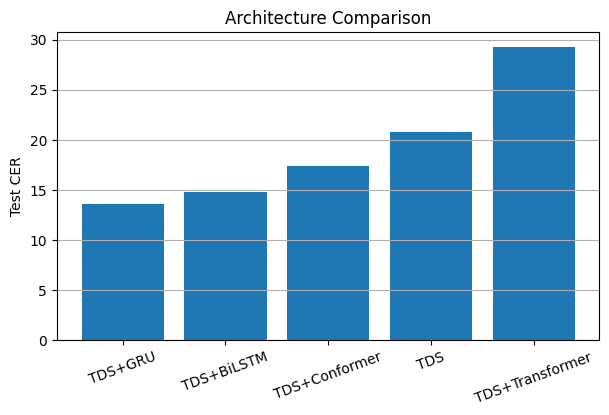

In [7]:
plot_arch_df = arch_df.copy()

plt.figure(figsize=(7, 4))
plt.bar(plot_arch_df["model_type"], plot_arch_df["test_CER"])
plt.ylabel("Test CER")
plt.title("Architecture Comparison")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.show()

## Best model details

In [8]:
best_row.to_frame(name="best_model_details")

,best_model_details
experiment_name,tds_gru_best
group,architecture
model_type,TDS+GRU
config_path,/home/bzhao29/emg2qwerty/config/model/tds_gru_...
checkpoint_path,/home/bzhao29/emg2qwerty/logs/2026-03-09/23-20...
augmentation,band_rotation+temporal_jitter
num_channels,32
train_fraction,1.0
sampling_rate,2000
epochs,80


## Preprocessing / augmentation results


In [9]:
aug_df = clean_df[clean_df["group"] == "augmentation"].copy()
aug_df = aug_df.sort_values("test_CER")

if len(aug_df) == 0:
    print("No completed augmentation experiments yet.")
else:
    display(aug_df[[
        "experiment_name",
        "model_type",
        "preprocessing",
        "augmentation",
        "val_CER",
        "test_CER",
        "DER",
        "IER",
        "SER",
        "notes"
    ]])

,experiment_name,model_type,preprocessing,augmentation,val_CER,test_CER,DER,IER,SER,notes
5,tds_gru_aug_jitter,TDS+GRU,NaN,temporal_jitter,12.649535,14.069592,1.491247,2.312514,10.265831,"TDS+GRU with temporal jitter; hidden_size=384,..."
6,tds_gru_full_aug,TDS+GRU,NaN,band_rotation+temporal_jitter+specaugment,13.934426,14.307326,1.231900,2.226064,10.849362,Full augmentation with TDS+GRU. Best checkpoin...
7,tds_gru_aug_specaug,TDS+GRU,NaN,specaugment,14.842711,15.712125,1.448022,2.550249,11.713854,"TDS+GRU with SpecAugment; hidden_size=384, num..."
8,tds_gru_aug_none,TDS+GRU,NaN,none,14.155959,16.425329,1.707370,2.701535,12.016425,"TDS+GRU with no augmentation; hidden_size=384,..."
9,tds_gru_aug_bandrot,TDS+GRU,NaN,band_rotation,15.706690,17.095310,1.577696,2.787984,12.729630,"TDS+GRU with band rotation; hidden_size=384, n..."
10,tds_gru_aug_band+spec,TDS+GRU,NaN,band_rotation + specaugmentation,16.747896,17.160147,1.728982,2.723147,12.708018,TDS+GRU with Band Rotation + SpecAugment; hidd...
11,tds_gru_aug_temp+spec,TDS+GRU,NaN,temp_jitter + specaugmentation,16.747896,17.160147,1.728982,2.723147,12.708018,TDS+GRU with Temporal Jitter + SpecAugment; hi...


## Number of channels vs CER


In [18]:
channels_df = clean_df[clean_df["group"] == "channel_count"].copy()
channels_df = channels_df.sort_values("num_channels")

display(channels_df[[
    "experiment_name",
    "model_type",
    "num_channels",
    "val_CER",
    "test_CER",
    "DER",
    "IER",
    "SER",
    "notes"
]])

,experiment_name,model_type,num_channels,val_CER,test_CER,DER,IER,SER,notes
14,tds_gru_8channels,TDS+GRU,8,32.676117,34.471581,3.414740,7.326561,23.730278,TDS+GRU using 8 total channels (4 per arm).
13,tds_gru_16channels,TDS+GRU,16,18.298626,19.105251,1.664145,3.544413,13.896693,TDS+GRU using 16 total channels (8 per arm).
12,tds_gru_24channels,TDS+GRU,24,14.798405,16.576616,1.231900,2.852820,12.491896,TDS+GRU using 24 total channels (12 per arm).


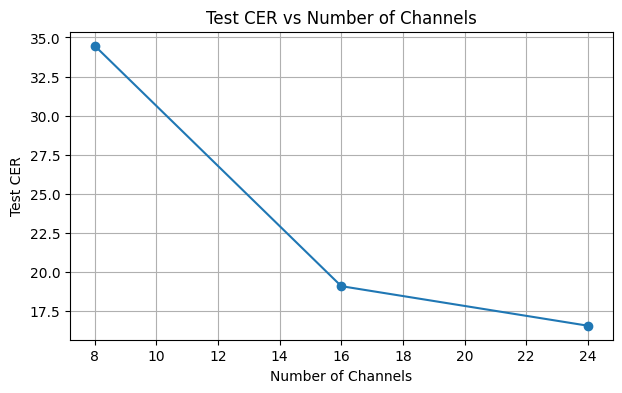

In [19]:
if len(channels_df) > 0:
    plt.figure(figsize=(7, 4))
    plt.plot(channels_df["num_channels"], channels_df["test_CER"], marker="o")
    plt.xlabel("Number of Channels")
    plt.ylabel("Test CER")
    plt.title("Test CER vs Number of Channels")
    plt.grid(True)
    plt.show()

## Training data fraction vs CER

The project explicitly asks for the relationship between amount of training data and CER. 

In [17]:
data_df = clean_df[clean_df["group"] == "data_amount"].copy()
data_df = data_df.sort_values("train_fraction")

display(data_df[[
    "experiment_name",
    "model_type",
    "train_fraction",
    "val_CER",
    "test_CER",
    "DER",
    "IER",
    "SER",
    "notes"
]])

,experiment_name,model_type,train_fraction,val_CER,test_CER,DER,IER,SER,notes
18,tds_gru_trainfrac_25,TDS+GRU,0.25,99.601242,100.000000,0.000000,100.000000,0.000000,"TDS+GRU, 25% training data, 40 epochs. Model f..."
17,tds_gru_trainfrac_50,TDS+GRU,0.50,25.852901,25.545710,2.485412,5.381457,17.678841,"TDS+GRU, 50% training data, 40 epochs."
16,tds_gru_trainfrac_75,TDS+GRU,0.75,17.922020,19.018803,1.620921,3.587638,13.810245,"TDS+GRU, 75% training data, 40 epochs."
15,tds_gru_trainfrac_100,TDS+GRU,1.00,14.953478,16.252432,1.620921,2.658310,11.973201,"TDS+GRU, 100% training data, 40 epochs."


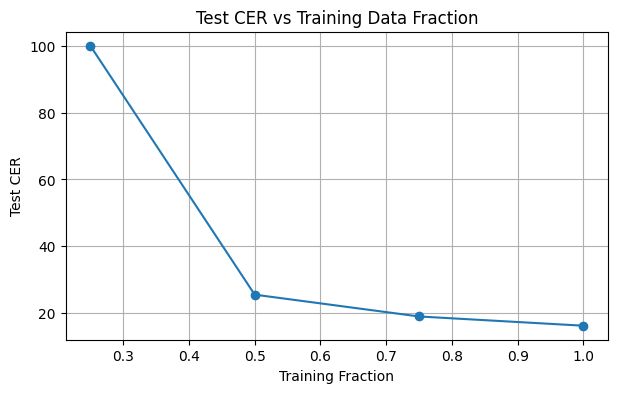

In [20]:
if len(data_df) > 0:
    plt.figure(figsize=(7, 4))
    plt.plot(data_df["train_fraction"], data_df["test_CER"], marker="o")
    plt.xlabel("Training Fraction")
    plt.ylabel("Test CER")
    plt.title("Test CER vs Training Data Fraction")
    plt.grid(True)
    plt.show()

## Sampling rate vs CER


In [21]:
sampling_df = clean_df[clean_df["group"] == "sampling_rate"].copy()
sampling_df = sampling_df.sort_values("sampling_rate")

display(sampling_df[[
    "experiment_name",
    "model_type",
    "sampling_rate",
    "val_CER",
    "test_CER",
    "DER",
    "IER",
    "SER",
    "notes"
]])

,experiment_name,model_type,sampling_rate,val_CER,test_CER,DER,IER,SER,notes
21,tds_gru_sampling_500Hz,TDS+GRU,500,61.408951,46.833801,0.453858,29.954615,16.425329,"TDS+GRU setup, factor=4 (500 Hz), 40 epochs."
20,tds_gru_sampling_1000Hz,TDS+GRU,1000,27.846699,21.547440,1.966717,5.684029,13.896693,"TDS+GRU setup, factor=2 (1000 Hz), 40 epochs."
19,tds_gru_sampling_2000Hz,TDS+GRU,2000,15.086398,15.496002,1.577696,2.679922,11.238383,"TDS+GRU setup, factor=1 (2000 Hz), 40 epochs."


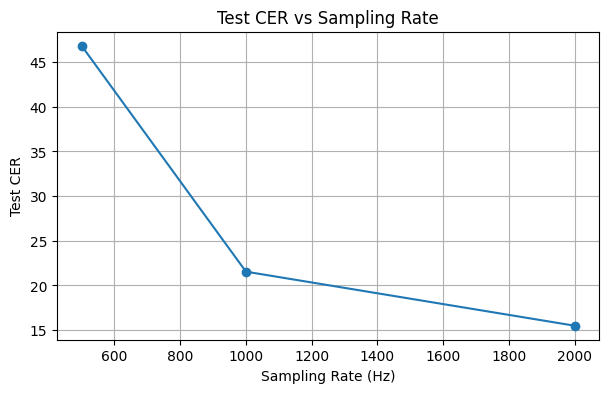

In [22]:
if len(sampling_df) > 0:
    plt.figure(figsize=(7, 4))
    plt.plot(sampling_df["sampling_rate"], sampling_df["test_CER"], marker="o")
    plt.xlabel("Sampling Rate (Hz)")
    plt.ylabel("Test CER")
    plt.title("Test CER vs Sampling Rate")
    plt.grid(True)
    plt.show()